In [1]:
!pip install google-generativeai

In [2]:
from google.colab import userdata
api_key = userdata.get('GOOGLE_API_KEY')

In [3]:
!pip install -q google-genai

In [4]:
from google import genai

client = genai.Client(api_key=api_key)

MODEL_NAME = "gemini-3.6-flash"
test_messages = [
    "URGENT: Your bank account will be BLOCKED in 24 hours. Verify now: bit.ly/secure-verify-now",
    "Hi beta, kal ka meeting 4pm ki jagah 5pm hoga, thoda late aana",
    "Congratulations! You've won a $1000 Amazon gift card. Claim here before it expires: amaz0n-rewards.com/claim",
    "Your OTP for login is 483920. Do not share this with anyone.",
    "Hey are we still on for dinner tonight?",
]

# --- Cell 4: The prompt we send for each message ---
SYSTEM_PROMPT = """You are a phishing/scam detection assistant. Given a message, analyze it for signs of
phishing, scam, or social engineering intent. Look specifically for:
- Urgency or pressure tactics
- Requests for sensitive info (OTP, password, PIN, bank details)
- Impersonation of a trusted entity (bank, government, delivery company, relative)
- Suspicious links or unrealistic offers

Respond ONLY in this exact format:
Risk: <Low/Medium/High>
Signals: <comma-separated list of triggered signals, or "None">
Explanation: <one sentence explaining the verdict>
"""


def analyze_message(message: str) -> str:
    """Send a single message to Gemini and return its raw text response."""
    full_prompt = f"{SYSTEM_PROMPT}\n\nMessage to analyze:\n{message}"
    response = client.models.generate_content(
        model=MODEL_NAME,
        contents=full_prompt,
    )
    return response.text

for i, msg in enumerate(test_messages, start=1):
    print(f"\n--- Message {i} ---")
    print(f"Text: {msg}")
    try:
        result = analyze_message(msg)
        print(f"Result:\n{result}")
    except Exception as e:
        print(f"Error calling API: {e}")


--- Message 1 ---
Text: URGENT: Your bank account will be BLOCKED in 24 hours. Verify now: bit.ly/secure-verify-now
Error calling API: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

--- Message 2 ---
Text: Hi beta, kal ka meeting 4pm ki jagah 5pm hoga, thoda late aana
Result:
Risk: Low
Signals: None
Explanation: The message is a benign informal schedule update with no malicious links, urgent demands, or requests for sensitive information.

--- Message 3 ---
Text: Congratulations! You've won a $1000 Amazon gift card. Claim here before it expires: amaz0n-rewards.com/claim
Result:
Risk: High
Signals: Urgency, Impersonation of a trusted entity, Suspicious link, Unrealistic offer
Explanation: The message uses an unrealistic gift card giveaway and an urgent deadline to trick recipients into visiting a suspicious domain impersonating Amazon.

--

In [5]:
!pip install -q scikit-learn pandas matplotlib seaborn



In [6]:
import pandas as pd
DATA_PATH = "/content/drive/MyDrive/Dataset_5971.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

print("\nClass distribution:")
print(df["LABEL"].value_counts())
print("\nClass distribution (%):")
print(df["LABEL"].value_counts(normalize=True) * 100)



Shape: (5971, 5)

Columns: ['LABEL', 'TEXT', 'URL', 'EMAIL', 'PHONE']

First few rows:
      LABEL                                               TEXT URL EMAIL PHONE
0       ham  Your opinion about me? 1. Over 2. Jada 3. Kusr...  No    No    No
1       ham  What's up? Do you want me to come online? If y...  No    No    No
2       ham                       So u workin overtime nigpun?  No    No    No
3       ham  Also sir, i sent you an email about how to log...  No    No    No
4  Smishing  Please Stay At Home. To encourage the notion o...  No    No    No

Class distribution:
LABEL
ham         4844
Smishing     616
spam         466
Spam          23
smishing      22
Name: count, dtype: int64

Class distribution (%):
LABEL
ham         81.125440
Smishing    10.316530
spam         7.804388
Spam         0.385195
smishing     0.368447
Name: proportion, dtype: float64


In [7]:
df = df.dropna(subset=["TEXT", "LABEL"])

# Normalize label casing just in case (ham/spam/smishing vs Ham/Spam/Smishing)
df["LABEL"] = df["LABEL"].str.strip().str.lower()

print("Cleaned class distribution:")
print(df["LABEL"].value_counts())



Cleaned class distribution:
LABEL
ham         4844
smishing     638
spam         489
Name: count, dtype: int64


In [8]:
# --- Cell 5: Train/test split (stratified, so class ratios are preserved in both sets) ---
from sklearn.model_selection import train_test_split

X = df["TEXT"]
y = df["LABEL"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80/20 split
    random_state=42,     # reproducibility
    stratify=y            # keeps class proportions consistent across train/test
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print("\nTrain class distribution:")
print(y_train.value_counts())
print("\nTest class distribution:")
print(y_test.value_counts())



Train size: 4776, Test size: 1195

Train class distribution:
LABEL
ham         3875
smishing     510
spam         391
Name: count, dtype: int64

Test class distribution:
LABEL
ham         969
smishing    128
spam         98
Name: count, dtype: int64


In [9]:
# --- Cell 6: TF-IDF Vectorization ---
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,    # cap vocabulary size to keep things fast
    ngram_range=(1, 2),   # unigrams + bigrams (bigrams help catch phrases like "act now")
    stop_words="english",
    lowercase=True,
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)  # note: transform only, not fit, on test data

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)



TF-IDF matrix shape (train): (4776, 5000)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

log_reg = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
log_reg.fit(X_train_tfidf, y_train)

svm = LinearSVC(
    class_weight="balanced",
    random_state=42
)
svm.fit(X_train_tfidf, y_train)

print("Both models trained.")



Both models trained.



Evaluation: Logistic Regression
              precision    recall  f1-score   support

         ham      0.985     0.992     0.988       969
    smishing      0.939     0.844     0.889       128
        spam      0.760     0.806     0.782        98

    accuracy                          0.961      1195
   macro avg      0.894     0.881     0.886      1195
weighted avg      0.961     0.961     0.961      1195



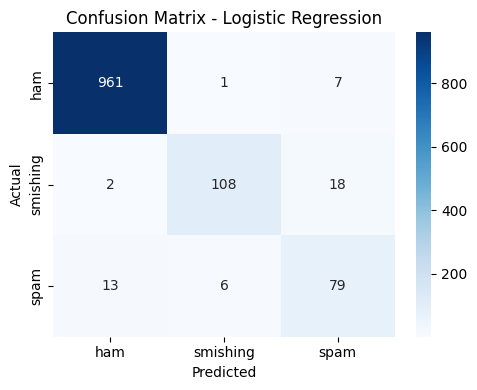


Evaluation: SVM (LinearSVC)
              precision    recall  f1-score   support

         ham      0.983     0.996     0.989       969
    smishing      0.930     0.836     0.881       128
        spam      0.776     0.776     0.776        98

    accuracy                          0.961      1195
   macro avg      0.896     0.869     0.882      1195
weighted avg      0.960     0.961     0.960      1195



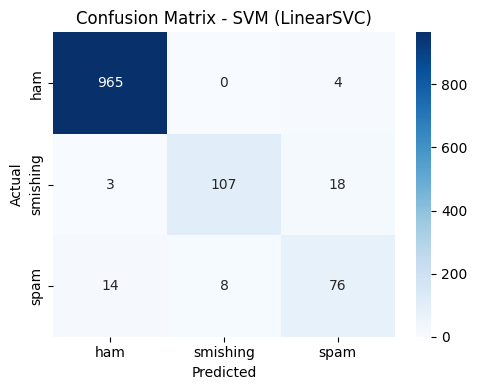

In [11]:
# --- Cell 8: Evaluation ---
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_test_vec, y_test, model_name):
    preds = model.predict(X_test_vec)

    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*50}")

    # classification_report gives precision/recall/F1 PER CLASS — this matters much more
    # than overall accuracy given the imbalance, especially recall on smishing/spam
    print(classification_report(y_test, preds, digits=3))

    # Confusion matrix — visualizes exactly which classes get confused with which
    cm = confusion_matrix(y_test, preds, labels=model.classes_)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    return preds

log_reg_preds = evaluate_model(log_reg, X_test_tfidf, y_test, "Logistic Regression")
svm_preds = evaluate_model(svm, X_test_tfidf, y_test, "SVM (LinearSVC)")



In [12]:
import joblib

joblib.dump(log_reg, "message_classifier_logreg.joblib")
joblib.dump(svm, "message_classifier_svm.joblib")
joblib.dump(vectorizer, "tfidf_vectorizer.joblib")

print("Saved: message_classifier_logreg.joblib, message_classifier_svm.joblib, tfidf_vectorizer.joblib")

Saved: message_classifier_logreg.joblib, message_classifier_svm.joblib, tfidf_vectorizer.joblib


In [13]:
def get_ml_verdict(message: str):
    vec = vectorizer.transform([message])
    prediction = log_reg.predict(vec)[0]
    probs = log_reg.predict_proba(vec)[0]
    classes = log_reg.classes_
    confidence = dict(zip(classes, probs))
    return prediction, confidence

SYSTEM_PROMPT = """You are a phishing/scam detection assistant. Given a message, analyze it for signs of
phishing, scam, or social engineering intent. Look specifically for:
- Urgency or pressure tactics
- Requests for sensitive info (OTP, password, PIN, bank details)
- Impersonation of a trusted entity (bank, government, delivery company, relative)
- Suspicious links or unrealistic offers

Respond ONLY in this exact format:
Risk: <Low/Medium/High>
Signals: <comma-separated list of triggered signals, or "None">
Explanation: <one sentence explaining the verdict>
"""

def get_llm_verdict(message: str) -> str:
    full_prompt = f"{SYSTEM_PROMPT}\n\nMessage to analyze:\n{message}"
    response = client.models.generate_content(
        model=MODEL_NAME,
        contents=full_prompt,
    )
    return response.text

In [14]:
message = "URGENT: Your bank account will be BLOCKED in 24 hours. Verify now: bit.ly/secure-verify-now"
# message = input("Enter a message to analyze: ")   # <-- uncomment for live typing during demo

print("=" * 60)
print(f"MESSAGE: {message}")
print("=" * 60)

ml_pred, ml_confidence = get_ml_verdict(message)
print("\n--- Classical ML Model (TF-IDF + Logistic Regression) ---")
print(f"Prediction: {ml_pred.upper()}")
print("Confidence scores:")
for label, score in sorted(ml_confidence.items(), key=lambda x: -x[1]):
    print(f"   {label}: {score:.2%}")

print("\n--- LLM Reasoning (Gemini) ---")
llm_result = get_llm_verdict(message)
print(llm_result)

print("\n" + "=" * 60)
print("COMBINED SYSTEM NOTE:")
print("In the full risk engine, these two signals (plus link analysis)")
print("will be combined into one final Low/Medium/High risk score.")
print("=" * 60)

MESSAGE: URGENT: Your bank account will be BLOCKED in 24 hours. Verify now: bit.ly/secure-verify-now

--- Classical ML Model (TF-IDF + Logistic Regression) ---
Prediction: SMISHING
Confidence scores:
   smishing: 46.92%
   ham: 38.87%
   spam: 14.21%

--- LLM Reasoning (Gemini) ---
Risk: High
Signals: Urgency tactics, Impersonation of a bank, Suspicious link
Explanation: The message uses artificial urgency and a suspicious shortened link to impersonate a bank and trick the recipient into providing sensitive account details.

COMBINED SYSTEM NOTE:
In the full risk engine, these two signals (plus link analysis)
will be combined into one final Low/Medium/High risk score.
